In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data

#### Customer Data

In [36]:
customers_df = pd.read_csv("../data/customers.csv", parse_dates=['signup_date'])
customers_df.head()

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


In [37]:
# Customer Samples and Columns
customers_df.shape

(2400, 9)

Customer Data 9 Features and 2400 Samples

In [38]:
customers_df.dtypes

customer_id                       str
signup_date            datetime64[us]
city_tier                         str
age_group                         str
acquisition_channel               str
loyalty_tier                      str
preferred_category                str
skin_type                         str
marketing_consent                 str
dtype: object

Customers DataFrame has 2400 unique customer_id, indicating no duplicated Customer entry in the table


### Orders Data

In [39]:
orders_df = pd.read_csv("../data/orders.csv", parse_dates=['order_date'])
orders_df.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


In [40]:
orders_df.shape

(10009, 10)

Order DataFrame has 10 Features and 10009 samples

In [41]:
orders_df.dtypes

order_id                    str
customer_id                 str
order_date       datetime64[us]
category                    str
quantity                  int64
gross_amount            float64
discount_pct            float64
delivery_days             int64
returned                  int64
rating                  float64
dtype: object

In [42]:
orders_df.describe()

,order_date,quantity,gross_amount,discount_pct,delivery_days,returned,rating
count,10009,10009.000000,10009.000000,10009.000000,10009.000000,10009.000000,9929.000000
mean,2025-04-14 01:17:41.404735,1.507943,743.898504,0.274121,4.454591,0.067439,3.885487
min,2024-01-09 00:00:00,1.000000,149.000000,0.000000,1.000000,0.000000,1.000000
25%,2024-12-19 00:00:00,1.000000,432.850000,0.190000,3.000000,0.000000,3.000000
50%,2025-05-08 00:00:00,1.000000,597.060000,0.270000,4.000000,0.000000,4.000000
75%,2025-09-06 00:00:00,2.000000,907.430000,0.360000,6.000000,0.000000,5.000000
max,2025-11-29 00:00:00,4.000000,24789.380000,0.700000,11.000000,1.000000,5.000000
std,NaN,0.764261,600.564068,0.125525,1.769649,0.250794,1.159465


In [43]:
orders_df[['customer_id', 'category', 'order_id']].describe()

,customer_id,category,order_id
count,10009,10009,10009
unique,2400,6,10009
top,CUST02154,Skin Care,ORD000001
freq,17,2700,1


the orders table has 2400 unique customer_id, indicating, every customer has made an order, with top order category being skin care, and top customer being customer CUST02154

### Support Tickets

In [44]:
support_tickets_df = pd.read_csv("../data/support_tickets.csv", parse_dates=['ticket_date'])
support_tickets_df.head()

,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
0,TKT000001,CUST00001,2024-10-28,damaged_item,chat,3.9,-0.16,0
1,TKT000002,CUST00001,2025-02-03,payment_issue,chat,4.8,0.44,0
2,TKT000003,CUST00002,2025-08-30,late_delivery,chat,1.0,0.00,0
3,TKT000004,CUST00005,2025-05-02,late_delivery,call,37.7,-1.00,0
4,TKT000005,CUST00006,2025-08-13,general_query,call,23.1,-0.68,1


In [45]:
support_tickets_df.shape

(1921, 8)

In [46]:
support_tickets_df.dtypes

ticket_id                      str
customer_id                    str
ticket_date         datetime64[us]
issue_type                     str
support_channel                str
resolution_hours           float64
sentiment_score            float64
reopened                     int64
dtype: object

Support Ticket DataFrame has 8 Feature and 1921 Samples

In [47]:
support_tickets_df[[ 'ticket_id', 'customer_id', 'issue_type', 'support_channel']].describe()

,ticket_id,customer_id,issue_type,support_channel
count,1921,1921,1921,1921
unique,1921,1247,7,3
top,TKT000001,CUST00042,late_delivery,email
freq,1,6,377,671


There are 1921 tickets in the support_tickets_df with unique ticket_id, but only 1247 unique customer_id, indicating, only 1247 has raised support tickets, with the top issue_type being around late_delivery<br/>
the most common support channel using which these ticket are raised is via email

### Web Events Snapshot Data

In [48]:
web_events_snapshot_df = pd.read_csv("../data/web_events_snapshot.csv", parse_dates=['snapshot_date'])
web_events_snapshot_df.head()

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9


In [49]:
web_events_snapshot_df.shape

(2400, 10)

In [50]:
web_events_snapshot_df.dtypes

customer_id                       str
snapshot_date          datetime64[us]
sessions_30d                    int64
product_views_30d               int64
cart_adds_30d                   int64
wishlist_adds_30d               int64
abandoned_carts_30d             int64
email_opens_30d                 int64
campaign_clicks_30d             int64
last_visit_days_ago             int64
dtype: object

## Aggregation And Joining Of Data

- all the tables has customer_id as a common key, we'll use this key for joining the tables
- support ticket has partial customer_id, which will need to be handled accordingly
- orders and support table have multiple rows per customer, they will need to be aggregated before joining the tables

In [51]:
snapshot_date = web_events_snapshot_df['snapshot_date'].max()
snapshot_date

Timestamp('2025-09-30 00:00:00')

Using snapshot date as 2025-09-30 from Web events snapshots

### Aggregating Orders Per Customer

In [52]:
LOOKBACK_DAYS = 180

date_upperlimit = snapshot_date
date_lowerlimit = snapshot_date - pd.Timedelta(days=LOOKBACK_DAYS)

Using Order Lookback window of 180 days for understanding customer's medium term buying behavior, as per business nature, D2C businesses has order frequency in that range for repeat orders and order cycle

In [53]:

# calculating over value 
orders_df['order_value'] = orders_df['gross_amount'] * (1 - orders_df['discount_pct'])

# Filtering Orders by order_date window, calculated from lookback days and snapshot_date, to prevent any data leakage
order_window = orders_df[(orders_df['order_date'] >= date_lowerlimit) & (orders_df['order_date'] <= date_upperlimit)]


rfm_df_180d = order_window.groupby('customer_id').agg(
    frequency_180d=('order_id', 'nunique'), # number of orders in 180 day
    monetary_180d=('gross_amount', 'sum'), # gross order value for order place in last 180 days
    return_rate_180d= ('returned', lambda x: round(x.mean(), 3)), # return rate of 180 days
    avg_discount_pct_180d= ('discount_pct', lambda x: round(x.mean(), 3)), # avg discount on orders purchased in order window
    avg_rating_180d=('rating', lambda x: round(x.mean(), 2)), # avg rating given to products
    category_diversity_180d=('category', 'nunique') # orders of different categories
)


# calculating recency days for customers since there last order
rfm_base = orders_df[orders_df['order_date'] <= date_upperlimit].groupby('customer_id').agg(
    recency_days=('order_date', lambda x: (snapshot_date - x.max()).days) # days since last order from snapshot days
).join(rfm_df_180d)

rfm_base.head()

,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d
customer_id,,,,,,,
CUST00001,107,1.0,362.73,0.0,0.23,3.0,1.0
CUST00002,40,1.0,581.00,0.0,0.23,4.0,1.0
CUST00003,171,1.0,649.98,0.0,0.47,2.0,1.0
CUST00004,131,1.0,1604.04,0.0,0.16,2.0,1.0
CUST00005,38,3.0,1781.90,0.0,0.48,1.0,2.0


### Aggregating Support Tickets metrics

In [54]:
TICKET_LOOKBACK_DAYS=90

ticket_date_upperlimit = snapshot_date
ticket_date_lowerlimit = snapshot_date - pd.Timedelta(days=TICKET_LOOKBACK_DAYS)

Lookback days of 90 days will be used for aggregating support tickets data, for understanding customer dissatisfaction, recent issues and problems faced by the customers

In [55]:
ticket_window_df = support_tickets_df[(support_tickets_df['ticket_date'] >= ticket_date_lowerlimit) & (support_tickets_df['ticket_date'] <= ticket_date_upperlimit)]

agg_ticket_df = pd.DataFrame()

# Ticket raised in last 90 days
agg_ticket_df['ticket_count_90d'] = ticket_window_df.groupby('customer_id').agg(
    ticket_count_90d=('ticket_id', 'count')
).round(2)

# Ticket with negative sentiments score showing bad experience faced by customers
agg_ticket_df['negative_ticket_rate_90d'] = ticket_window_df.groupby('customer_id').agg(
    negative_ticket_rate_90d=('sentiment_score', lambda x: (x < 0).mean()),
).round(2)

# Average resolution hours it took to resolve the tickets raised by the customer
agg_ticket_df['avg_resolution_hours_90d'] = ticket_window_df.groupby('customer_id').agg(
    avg_resolution_hours_90d=('resolution_hours','mean')
).round(2)

agg_ticket_df.head()

,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d
customer_id,,,
CUST00002,1,0.0,1.0
CUST00006,2,1.0,17.6
CUST00021,1,1.0,20.1
CUST00026,1,1.0,20.0
CUST00027,1,1.0,8.0


### Joining DataFrames

Selecting Columns from Data which display and helps us understand customer behavior, only those selected columns will be used in the final merged data for data analysis

Creating Customer Engagement Data Frame using Web Events to understand engagement of the customer with the platform

In [56]:
customer_engagement_df = pd.DataFrame()
customer_engagement_df['customer_id'] = customers_df['customer_id']
customer_engagement_df['days_since_signup'] = (snapshot_date - customers_df['signup_date']).dt.days

web_events_cols = ['sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago']

customer_engagement_df[web_events_cols] = web_events_snapshot_df[web_events_cols]
customer_engagement_df.head()

,customer_id,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,524,1,4,0,0,0,2,0,20
1,CUST00002,121,8,31,4,2,3,0,0,0
2,CUST00003,206,1,3,0,0,0,0,0,26
3,CUST00004,168,1,6,0,0,0,0,0,14
4,CUST00005,405,18,95,4,1,1,3,1,9


Merging Curated Tables into a Merged Customer DataFrame

In [57]:
# dropping signup_date because it's used in customer_engagement_df, and skin_type because it's irrelevant to customer behavior
customer_details_df = customers_df.drop(columns=['signup_date', 'skin_type'])

customer_merged_df = (customer_details_df.set_index('customer_id')
 .join(rfm_base)
 .join(agg_ticket_df)
 .join(customer_engagement_df.set_index('customer_id'))
 ).reset_index()

customer_merged_df.head()

,customer_id,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,...,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1.0,362.73,...,NaN,524,1,4,0,0,0,2,0,20
1,CUST00002,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1.0,581.00,...,1.0,121,8,31,4,2,3,0,0,0
2,CUST00003,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1.0,649.98,...,NaN,206,1,3,0,0,0,0,0,26
3,CUST00004,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1.0,1604.04,...,NaN,168,1,6,0,0,0,0,0,14
4,CUST00005,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3.0,1781.90,...,NaN,405,18,95,4,1,1,3,1,9


#### Imputing Null Columns

Customers Who did not fall in the order window or have not raised any ticket recently have null values in the aggregated columns, Imputing them with 0 value

In [58]:
cols = [ 'category_diversity_180d', 'ticket_count_90d', 'frequency_180d', 'monetary_180d', 'return_rate_180d',
    'avg_resolution_hours_90d', 'avg_discount_pct_180d', 'negative_ticket_rate_90d' ]

customer_merged_df[cols] = customer_merged_df[cols].fillna(0)

# imputing avg_rating with mean where rating is null
customer_merged_df['avg_rating_180d'] = customer_merged_df['avg_rating_180d'].fillna(customer_merged_df['avg_rating_180d'].mean())


In [59]:
quantiles = customer_merged_df[['recency_days', 'frequency_180d', 'monetary_180d', 'days_since_signup']].quantile(q=[0.20, 0.40, 0.60, 0.80])

def rfmScore(val, col, quantiles):
    if col == 'recency_days' or col == 'days_since_signup':
        if val <= quantiles[col][0.20]:
            return 5
        elif val <= quantiles[col][0.40]:
            return 4
        elif val <= quantiles[col][0.60]:
            return 3
        elif val <= quantiles[col][0.80]:
            return 2
        else:
            return 1
    else:
        if val <= quantiles[col][0.80]:
            return 5
        elif val <= quantiles[col][0.60]:
            return 4
        elif val <= quantiles[col][0.40]:
            return 3
        elif val <= quantiles[col][0.20]:
            return 2
        else:
            return 1

customer_merged_df['R_score'] = customer_merged_df['recency_days'].apply(rfmScore, args=('recency_days', quantiles))
customer_merged_df['F_score'] = customer_merged_df['frequency_180d'].apply(rfmScore, args=('frequency_180d', quantiles))
customer_merged_df['M_score'] = customer_merged_df['monetary_180d'].apply(rfmScore, args=('monetary_180d', quantiles))
customer_merged_df['signup_recency'] = customer_merged_df['days_since_signup'].apply(rfmScore, args=('days_since_signup', quantiles))

customer_merged_df.head()

,customer_id,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,...,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,R_score,F_score,M_score,signup_recency
0,CUST00001,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1.0,362.73,...,0,0,0,2,0,20,2,5,5,1
1,CUST00002,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1.0,581.00,...,4,2,3,0,0,0,4,5,5,5
2,CUST00003,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1.0,649.98,...,0,0,0,0,0,26,1,5,5,4
3,CUST00004,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1.0,1604.04,...,0,0,0,0,0,14,2,5,5,4
4,CUST00005,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3.0,1781.90,...,4,1,1,3,1,9,4,1,5,2


In [60]:
customer_merged_df[['recency_days', 'frequency_180d', 'monetary_180d']].describe()

,recency_days,frequency_180d,monetary_180d
count,2400.000000,2400.000000,2400.000000
mean,87.375833,1.595833,1184.740429
std,80.137473,1.185918,1058.092553
min,0.000000,0.000000,0.000000
25%,25.000000,1.000000,449.270000
50%,66.000000,1.000000,912.175000
75%,129.000000,2.000000,1685.405000
max,562.000000,8.000000,11655.310000


In [61]:
# Defining Customer Segment
def define_segment(val):
    if val['R_score'] >= 4 and val['F_score'] >= 4 and val['M_score'] >= 4:
        return 'Champion'
    elif val['R_score'] >= 3 and val['F_score'] >= 4:
        return 'Loyal'
    elif val['R_score'] >= 2 and val['F_score'] >= 2 and val['avg_discount_pct_180d'] >= 0.30:
        return 'Discount-sensitive'
    elif val['R_score'] >= 2 and val['F_score'] >= 2 and val['signup_recency'] >= 3:
        return 'Recent Customer'
    elif val['F_score'] <= 2 and val['M_score'] >= 4: 
        return 'Infrequent - High Spender'
    elif val['R_score'] <= 2 and (val['F_score'] >= 3 or val['M_score'] >= 3):
        return 'At-Risk'
    elif val['R_score'] <= 2 and val['F_score'] <= 2: 
        return 'Dormant'
    elif val['F_score'] <= 2 and val['M_score'] <= 2: 
        return 'Infrequent - Low Spender'
    else:
        return 'Others'

In [62]:
customer_merged_df['RFM_Segment'] = customer_merged_df.apply(define_segment, axis=1)
customer_merged_df

,customer_id,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,...,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,R_score,F_score,M_score,signup_recency,RFM_Segment
0,CUST00001,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1.0,362.73,...,0,0,2,0,20,2,5,5,1,At-Risk
1,CUST00002,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1.0,581.00,...,2,3,0,0,0,4,5,5,5,Champion
2,CUST00003,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1.0,649.98,...,0,0,0,0,26,1,5,5,4,At-Risk
3,CUST00004,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1.0,1604.04,...,0,0,0,0,14,2,5,5,4,Recent Customer
4,CUST00005,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3.0,1781.90,...,1,1,3,1,9,4,1,5,2,Infrequent - High Spender
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,CUST02396,Tier 2,35-44,Instagram,NaN,Baby Care,No,114,1.0,553.88,...,0,0,0,0,42,2,5,5,4,Recent Customer
2396,CUST02397,Tier 1,25-34,Marketplace,Silver,Fragrance,Yes,58,1.0,451.68,...,1,2,3,1,25,3,5,5,5,Loyal
2397,CUST02398,Tier 2,45+,Google Search,NaN,Hair Care,Yes,49,2.0,1168.26,...,0,1,0,0,10,3,5,5,2,Loyal
2398,CUST02399,Tier 1,45+,Instagram,NaN,Wellness,Yes,276,0.0,0.00,...,0,1,5,1,60,1,5,5,2,At-Risk


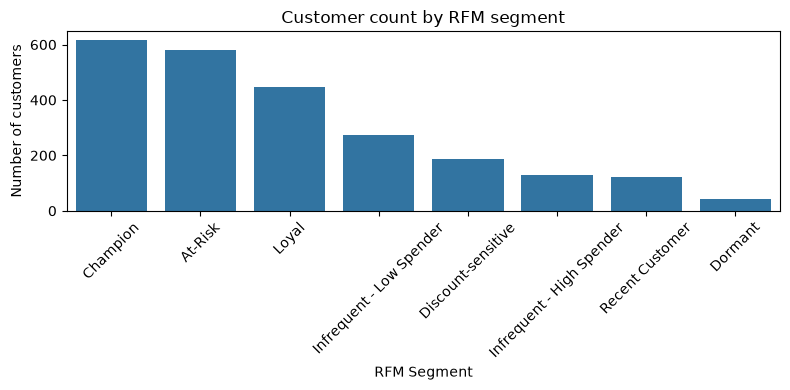

In [66]:
plt.figure(figsize=(8, 4))
segment_counts = customer_merged_df['RFM_Segment'].value_counts().sort_values(ascending=False)
sns.barplot(x=segment_counts.index, y=segment_counts.values)
plt.xticks(rotation=45)
plt.ylabel('Number of customers')
plt.xlabel('RFM Segment')
plt.title('Customer count by RFM segment')
plt.tight_layout()
plt.show()

Champion is the biggest customer segment, then At-Risk and Then Loyal

In [ ]:
# Saving Customer Segmentation
customer_segments = pd.DataFrame()
customer_segments['customer_id'] = customer_merged_df['customer_id']
customer_segments['segment'] = customer_merged_df['RFM_Segment']
customer_segments.to_csv('../segments.csv', index=False)